In [2]:
# 범주가 아니라 숫자를 예측
# ex)집값 등 연속적인 숫자를 예측 (과거자료를 기반으로 추후를 예측)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

import warnings
warnings.filterwarnings("ignore")

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns = housing.feature_names)
df["PRICE"] = housing.target

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


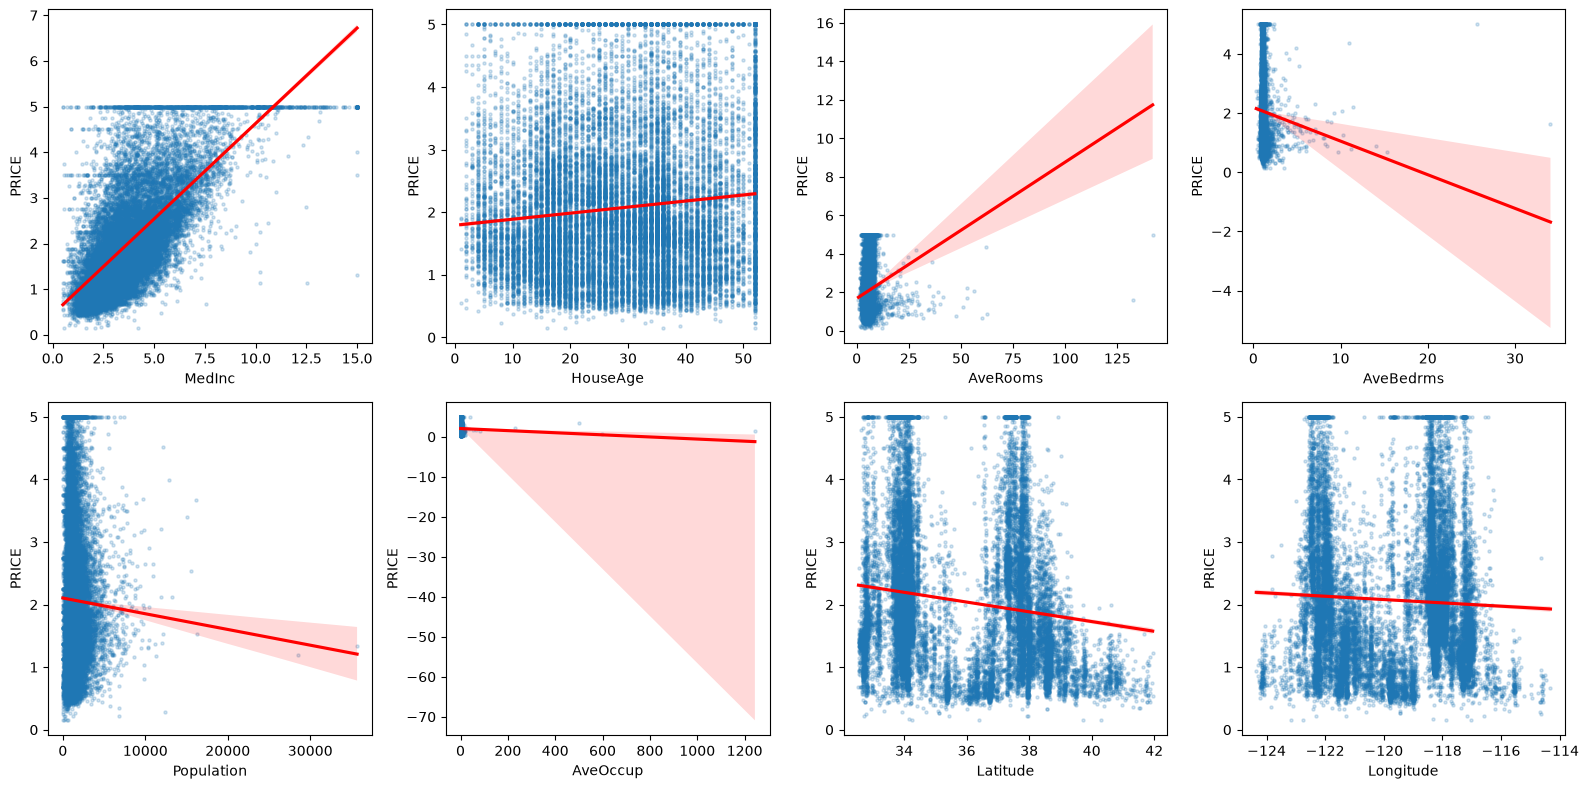

In [4]:
fig, axs = plt.subplots(figsize = (16, 8), ncols = 4, nrows = 2)
lm_features = ["MedInc",
               "HouseAge",
               "AveRooms",
               "AveBedrms",
               "Population",
               "AveOccup",
               "Latitude",
               "Longitude"]

for i, feature in enumerate(lm_features):
    row = int(i / 4) # 몫 계산
    col = i % 4 # 나머지 계산
    sns.regplot(x = feature,
                y = "PRICE",
                data = df,
                ax = axs[row][col],
                scatter_kws = {"s" : 5, "alpha" : 0.2}, # 산점도를 그리고 라인을 그음 = 산점도의 추세를 확인하기 위함
                line_kws = {"color":"red"}) # 다른 색상의 지정으로 변수의 추세를 명확하게 확인

plt.tight_layout()
fig1 = plt.gcf()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = df["PRICE"]
X_data = df.drop(["PRICE"], axis = 1, inplace = False)

X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_target,
                                                    test_size = 0.3,
                                                    random_state = 42)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(pred) # 가격(PRICE)을 예상) , X에 대한 INDEX를 예상
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(mse)
print(rmse)
print(r2_score(y_test, pred))

[0.72604907 1.76743383 2.71092161 ... 2.07465531 1.57371395 1.82744133]
0.530567782476675
0.7284008391515451
0.5957702326061665


In [6]:
# 절편(y = ax + b 의 b)값 타겟변수 (y,PRICE)의 기본 예측값
# 회귀계수 값

In [7]:
print(lr.intercept_) # 절편 값
print(np.round(lr.coef_, 3)) # (a값=기울기) 회귀계수의 회귀선, 기울기를 구함

-37.0562413315252
[ 0.446  0.01  -0.122  0.779 -0.    -0.003 -0.419 -0.434]


In [8]:
# 회귀계수를 판다스 Series로 변환, 인덱스를 컬럼명으로 지정 > 영향을 주는 것을 확인
coeff = pd.Series(data = np.round(lr.coef_, 3), index = X_data.columns)
# 값이 큰 순서대로 내림차순 정렬하여 출력하여 확인 / 분류랑 다르게 회귀는 반드시 꼭 보아서 확인해야함
coeff.sort_values(ascending=False)

AveBedrms     0.779
MedInc        0.446
HouseAge      0.010
Population   -0.000
AveOccup     -0.003
AveRooms     -0.122
Latitude     -0.419
Longitude    -0.434
dtype: float64

In [9]:
from sklearn.model_selection import cross_val_score # 5-폴드 교차검증을 수행하여 모델성능평가

y_target = df["PRICE"]
X_data = df.drop(["PRICE"], axis = 1 , inplace = False)
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr,
                                 X_data,
                                 y_target,
                                 scoring = "neg_mean_squared_error", #음수를 사용
                                 cv = 5) #5폴드 사용

rmse_scores = np.sqrt(-1 * neg_mse_scores) # 음수(neg)를 사용하였으니 -1을 곱해줘야 원값으로 돌아옴
avg_rmse = np.mean(rmse_scores)

print(np.round(neg_mse_scores, 2))
print(np.round(rmse_scores, 2))
print(avg_rmse)

[-0.48 -0.62 -0.65 -0.54 -0.49]
[0.7  0.79 0.8  0.74 0.7 ]
0.7459068363518113


In [10]:
# 다항회귀 = 항이 여러개 있다. ex) y=a1,a2,a3.. 같은

In [11]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(4).reshape(2,2)
print("일차 단항식 계수", X)

poly = PolynomialFeatures(degree = 2)
poly.fit(X)
poly_ftr = poly.transform(X)
print("변환된 2차 다항식 계수", poly_ftr)

일차 단항식 계수 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [12]:
def polynomial_func(X):
    y = 1 + 2 * X[:,0] + 3 * X[:,0]**2 + 4 * X[:,1] **3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0, 4).reshape(2, 2)

print("일차 단항식 계수", X)
y = polynomial_func(X)
print("삼차 다항식 결정값", y)

일차 단항식 계수 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값 [  5 125]


In [13]:
# 회귀 계수 구하기
poly_ftr = PolynomialFeatures(degree = 3).fit_transform(X) # 삼차 다항식으로 변형
print("3차 다항식 계수", poly_ftr)

model = LinearRegression()
model.fit(poly_ftr, y)
print("회귀 계수", np.round(model.coef_, 2))
print("회귀 shape", model.coef_.shape)
#과소 적합과 과적합을 알기 위해서 하는것

3차 다항식 계수 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
회귀 계수 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
회귀 shape (10,)


In [14]:
# 파이프 라인 (작성하면 여러줄로 나누어 쓴 코드를 한줄로 정리해주는)
# 구축할줄 알아야함

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 2 + 2*X[:, 0] + 3*X[:, 0]**2 + 4*X[:, 1]**3
    return y

model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("linear", LinearRegression())
])

X = np.arange(4).reshape(2, 2)
y= polynomial_func(X)

model = model.fit(X, y)
print("회귀 계수", np.round(model.named_steps["linear"].coef_, 2))

회귀 계수 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


In [16]:
# 다항 회귀를 이용한 과소적합과 과적합

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score # 교차검증으로 모델성능 평가

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

y = true_fun(X) + np.random.rand(n_samples) * 0.1

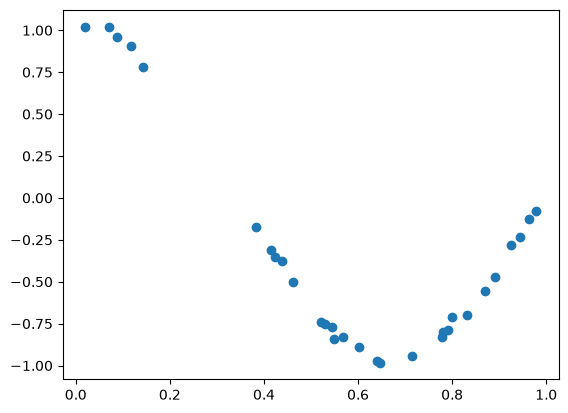

In [18]:
plt.scatter(X, y)

Degree 1
회귀 계수 [-1.52]
MSE 0.38559805246752143
Degree 4
회귀 계수 [  1.74 -22.98  31.58 -11.24]
MSE 0.005719308263123751
Degree 15
회귀 계수 [   4.02  -59.97  208.4  -318.7    82.52  198.58   27.86 -117.09 -116.34
  -23.58   62.34   79.97   30.05  -33.59  -25.52]
MSE 0.056263308763958145


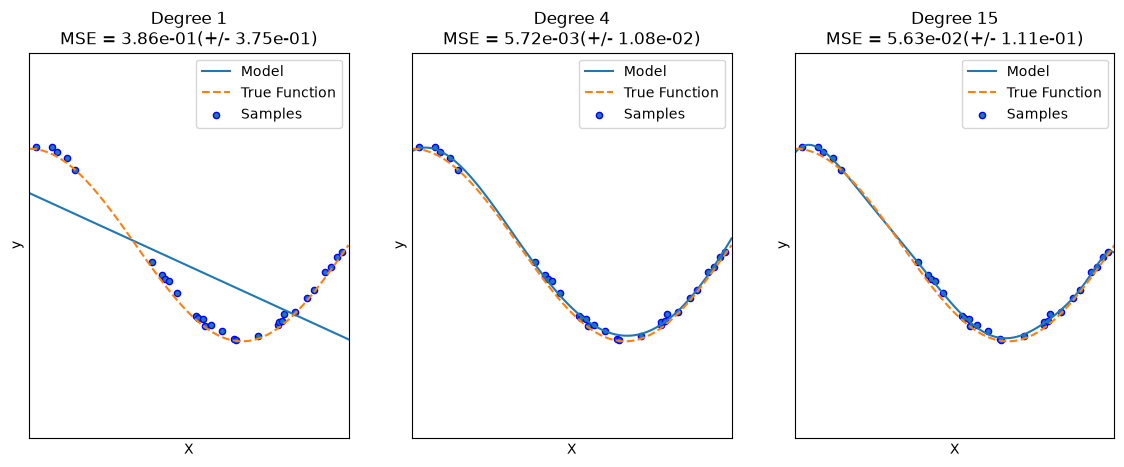

In [19]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])

    pipeline.fit(X.reshape(-1, 1), y)

    scores = cross_val_score(pipeline,
                             X.reshape(-1, 1),
                             y,
                             scoring="neg_mean_squared_error",
                             cv=10)

# coefficitent = 회귀 계수
    coefficients = pipeline.named_steps["linear_regression"].coef_
    print("Degree", degrees[i])
    print("회귀 계수", np.round(coefficients, 2))
    print("MSE", -1 * np.mean(scores))

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), "--", label="True Function")
    plt.scatter(X, y, edgecolor="b", s=20, label="Samples")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(f"Degree {degrees[i]}\nMSE = {-scores.mean():.2e}(+/- {scores.std():.2e})") # 교수님 쓰는것과 다름 확인하여 인지할것

plt.show()

# 1 은 과소적합(점을 많이 지나지 못하는) , 15 는 과대적합(점을따라 그린)

In [21]:
# 편향과 분산

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns = housing.feature_names)

df["PRICE"] = housing.target

y_target = df["PRICE"]
X_data = df.drop(["PRICE"], axis = 1, inplace = False)

ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge,
                                 X_data,
                                 y_target,
                                 scoring = "neg_mean_squared_error",
                                 cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print("Negative MSE", np.round(neg_mse_scores, 3))
print("RMSE", np.round(rmse_scores, 3))
print("Average RMSE", avg_rmse)

Negative MSE [-0.484 -0.623 -0.646 -0.544 -0.494]
RMSE [0.695 0.789 0.804 0.737 0.703]
Average RMSE 0.745820729297258


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)
# Claude 추천 

alphas = [0, 0.1, 1, 10, 100] # alpha를 0~100 까지 다섯단계로 모델생성, alpha가 커질수록 계수가 더 많이 억제

for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    neg_mse_scores = cross_val_score(ridge,
                                     X_scaled,
                                     y_target,
                                     scoring = "neg_mean_squared_error",
                                     cv = 5)

    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print("alpha{0}, RMSE{1:.8f}".format(alpha, avg_rmse))

alpha0, RMSE0.74590684
alpha0.1, RMSE0.74590621
alpha1, RMSE0.74590066
alpha10, RMSE0.74585341
alpha100, RMSE0.74606981


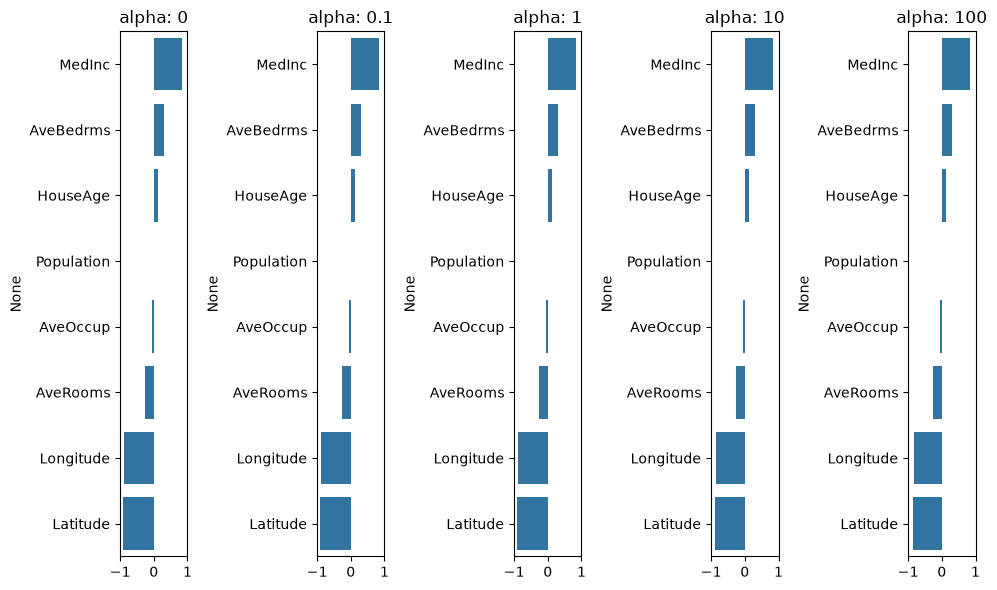

In [35]:
fig, axs = plt.subplots(figsize = (10, 6), nrows = 1, ncols =5)

coeff_df = pd.DataFrame()

for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_scaled, y_target)
    coeff = pd.Series(data = ridge.coef_, index = X_data.columns)
    colname = "alpha: " + str(alpha)
    coeff_df[colname] = coeff
    coeff = coeff.sort_values(ascending = False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-1, 1)
    sns.barplot(x = coeff.values, 
                y = coeff.index,
                ax = axs[pos])

plt.tight_layout()
plt.show()

In [36]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = "alpha: " + str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending = False)

,alpha: 0,alpha: 0.1,alpha: 1,alpha: 10,alpha: 100
MedInc,0.829619,0.829617,0.829593,0.829346,0.826391
AveBedrms,0.305696,0.305679,0.305525,0.303981,0.288706
HouseAge,0.118752,0.118758,0.118817,0.119398,0.124725
Population,-0.004503,-0.004501,-0.004480,-0.004275,-0.002398
AveOccup,-0.039326,-0.039327,-0.039330,-0.039361,-0.039619
AveRooms,-0.265527,-0.265514,-0.265397,-0.264223,-0.252284
Longitude,-0.870541,-0.870478,-0.869916,-0.864337,-0.812634
Latitude,-0.899886,-0.899824,-0.899266,-0.893739,-0.842577


In [ ]:
from sklearn.linear_model import Lasso, ElasticNet

def get_linear_reg_eval(model_name,
                         params=None,
                         X_data_n=None,
                         y_target_n=None,
                         verbose=True,
                         return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose: print("#####", model_name, "#####")
    for param in params:
        if model_name == "Ridge": model = Ridge(alpha=param)
        elif model_name == "Lasso": model = Lasso(alpha=param)
        elif model_name == "ElasticNet":
            model = ElasticNet(alpha=param, l1_ratio=0.7)

        neg_mse_scores = cross_val_score(model,
                                         X_data_n,
                                         y_target_n,
                                         scoring="neg_mean_squared_error",
                                         cv=5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print("alpha {0} rmse {1}".format(param, avg_rmse))

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            coeff = pd.Series(data=model.coef_,
                              index=X_data_n.columns)
            colname = "alpha: " + str(param)
            coeff_df[colname] = coeff

    return coeff_df

In [46]:
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval("Lasso",
                                     params = lasso_alphas,
                                     X_data_n = X_data,
                                     y_target_n = y_target)

##### Lasso #####
alpha 0.07 rmse 0.7843330816065585
alpha 0.1 rmse 0.8126415820543167
alpha 0.5 rmse 0.8726693609660868
alpha 1 rmse 0.999589987374003
alpha 3 rmse 1.1710496863773499


In [47]:
sort_columns = "alpha: " + str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_columns, ascending = False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
MedInc,0.387057,0.390583,0.288855,0.145469,0.000000
HouseAge,0.013391,0.015082,0.012031,0.005815,0.000000
Population,0.000010,0.000018,0.000012,-0.000006,-0.000023
AveRooms,-0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,0.000000,0.000000
AveOccup,-0.003409,-0.003323,-0.000000,-0.000000,-0.000000
Longitude,-0.204689,-0.099225,-0.000000,-0.000000,0.000000
Latitude,-0.212806,-0.114214,-0.000000,-0.000000,0.000000


In [ ]:
elastic_alphas = [0.07, 0.1, 0.5, 1, 3] # ElasticNet 은 Feature가 많을 때 사용하면 좋음
coeff_ealasitc_df = get_linear_reg_eval("ElasticNet",
                                     params = elastic_alphas,
                                     X_data_n = X_data,
                                     y_target_n = y_target)

##### ElasticNet #####
alpha 0.07 rmse 0.7726785226676597
alpha 0.1 rmse 0.788418026507988
alpha 0.5 rmse 0.8547105083610005
alpha 1 rmse 0.9306776387948424
alpha 3 rmse 1.1710447342550145


In [55]:
sort_columns = "alpha: " + str(elastic_alphas[0])
coeff_ealasitc_df.sort_values(by = sort_columns, ascending = False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
MedInc,0.384500,0.385980,0.318532,0.213455,0.000000
HouseAge,0.012534,0.013697,0.013662,0.009156,0.000000
Population,0.000007,0.000012,0.000018,0.000003,-0.000023
AveRooms,0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,-0.000000,0.000000
AveOccup,-0.003502,-0.003437,-0.000837,-0.000000,-0.000000
Longitude,-0.259559,-0.185737,-0.000000,-0.000000,-0.000000
Latitude,-0.264115,-0.195109,-0.000000,-0.000000,-0.000000


In [ ]:
# 회귀를 사용할 때 스케일 하면 규제모델 성능이 높아짐 / 스케일링, 로그변환

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

def get_scaled_data(method = None, p_degree = None, input_data = None):
    if method == "Standard":
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == "MinMax":
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == "Log":
        scaled_data = input_data.copy()
        positive_cols = scaled_data.columns[(scaled_data >- 0).all()]
        scaled_data[positive_cols] = np.log1p(scaled_data[positive_cols])
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree = p_degree,
                                         include_bias = False).fit_transform(scaled_data)

    return scaled_data

In [ ]:
# 회귀를 사용할 때 이렇게 하나하나 찍어보는것을 추천
# 규제를 다 사용해서 돌려보아야 유의미한 값을 확인
# 회귀를 사용하면 가장 fit한 값을 찾아야 함

alphas = [0.1, 1, 10, 100]

scaled_methods = [(None, None), ("Standard", None), ("Standard", 2),
                  ("MinMax", None), ("MinMax", 2), ("Log", None)]

for scaled_method in scaled_methods:
    X_data_scaled = get_scaled_data(method=scaled_method[0],
                                    p_degree=scaled_method[1],
                                    input_data=X_data)

    print(X_data_scaled.shape, X_data.shape)
    print(scaled_method[0], scaled_method[1])
    get_linear_reg_eval("Ridge",
                        params=alphas,
                        X_data_n=X_data_scaled,
                        y_target_n=y_target,
                        verbose=False,
                        return_coeff=False)

(20640, 8) (20640, 8)
None None
alpha 0.1 rmse 0.7459058975815243
alpha 1 rmse 0.7458975215245666
alpha 10 rmse 0.745820729297258
alpha 100 rmse 0.7455621549159899
(20640, 8) (20640, 8)
Standard None
alpha 0.1 rmse 0.7459062101326919
alpha 1 rmse 0.7459006592292845
alpha 10 rmse 0.7458534119763472
alpha 100 rmse 0.7460698057804251
(20640, 44) (20640, 8)
Standard 2
alpha 0.1 rmse 3.322648006406444
alpha 1 rmse 2.850331833488543
alpha 10 rmse 1.313763176046886
alpha 100 rmse 0.7186881531785737
(20640, 8) (20640, 8)
MinMax None
alpha 0.1 rmse 0.7446135691916066
alpha 1 rmse 0.747698395099562
alpha 10 rmse 0.753910122049269
alpha 100 rmse 0.8162438280708215
(20640, 44) (20640, 8)
MinMax 2
alpha 0.1 rmse 0.7257311172484077
alpha 1 rmse 0.7424165229389478
alpha 10 rmse 0.7553401447762835
alpha 100 rmse 0.7890551890075603
(20640, 8) (20640, 8)
Log None
alpha 0.1 rmse 0.7305763496807778
alpha 1 rmse 0.7315332186967523
alpha 10 rmse 0.7542834302658961
alpha 100 rmse 0.795037262770435
